# T4 — Preprocesamiento de Texto y Comparación de Modelos Base (TF-IDF)

**Tesis:** "Diseño e Implementación de un Sistema de Recomendación Laboral  
para Optimizar el Matching entre Candidatos y Ofertas de Empleo"  
**Alumno:** Cicconi, Carlos Alberto  
**Maestría:** Explotación de Datos y Gestión del Conocimiento — Universidad Austral  
**Período estimado:** 01/01/2026 – 15/01/2026

---

## Objetivos de esta etapa

| # | Objetivo |
|---|----------|
| 1 | Preprocesar el texto de las ofertas y del CV (tokenización, stop-words, lemmatización) |
| 2 | Construir el documento del CV en formato comparable a las ofertas |
| 3 | Vectorizar con **TF-IDF** (modelo base del benchmark) |
| 4 | Calcular similitud coseno CV ↔ cada oferta |
| 5 | Generar el **ranking baseline** de ofertas recomendadas |
| 6 | Analizar la calidad del ranking y detectar sus limitaciones semánticas |
| 7 | Guardar vectores y ranking para comparación posterior con T5 (embeddings) |

### Inputs
- `ofertas_con_descripcion.csv` — 1 279 ofertas con descripción útil (salida de T3)
- `CarlosA_Cicconi_CV.pdf` — CV del candidato

### Outputs
- `cv_texto_limpio.txt` — texto preprocesado del CV
- `ofertas_preprocesadas.csv` — corpus con columna `texto_procesado`
- `tfidf_ranking_baseline.csv` — ranking de ofertas ordenadas por similitud TF-IDF
- `tfidf_vectorizer.pkl` / `tfidf_matrix.pkl` — artefactos para T5/T6


## 0. Configuración del entorno

In [1]:
# ── Instalación de dependencias NLP ──────────────────────────────────────────
# Ejecutar UNA SOLA VEZ si el entorno no tiene estas librerías
# NOTA: pickle5 NO es necesario en Python 3.8+; pickle viene en la stdlib.
# !pip install spacy langdetect scikit-learn pandas numpy matplotlib seaborn
# !python -m spacy download es_core_news_md
# !python -m spacy download en_core_web_md


In [2]:
import re
import pickle
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import spacy

# Detección de idioma
try:
    from langdetect import detect as langdetect_detect
    HAS_LANGDETECT = True
except ImportError:
    HAS_LANGDETECT = False
    print("⚠️  langdetect no disponible — se usará heurística propia")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

# ── Cargar modelos spaCy ──────────────────────────────────────────────────────
try:
    nlp_es = spacy.load("es_core_news_md")
    print("✅ spaCy es_core_news_md cargado")
except OSError:
    nlp_es = spacy.load("es_core_news_sm")
    print("⚠️  Usando es_core_news_sm (md no disponible)")

try:
    nlp_en = spacy.load("en_core_web_md")
    print("✅ spaCy en_core_web_md cargado")
except OSError:
    nlp_en = spacy.load("en_core_web_sm")
    print("⚠️  Usando en_core_web_sm (md no disponible)")

# ── Rutas del proyecto (resueltas desde la ubicación del notebook) ────────────
from pathlib import Path
_NB   = Path(globals().get('__vsc_ipynb_file__', Path.cwd())).resolve()
_ROOT = _NB.parent if _NB.name != 'notebooks' else _NB.parent
if _ROOT.name == 'notebooks': _ROOT = _ROOT.parent
_PROC    = _ROOT / 'data'    / 'processed'
_CVDIR   = _ROOT / 'data'    / 'cvs'
_MODELS  = _ROOT / 'outputs' / 'models'
_RANKINGS= _ROOT / 'outputs' / 'rankings'
_FIGS    = _ROOT / 'outputs' / 'figures'
_PROC.mkdir(parents=True, exist_ok=True)
_MODELS.mkdir(parents=True, exist_ok=True)
_RANKINGS.mkdir(parents=True, exist_ok=True)
_FIGS.mkdir(parents=True, exist_ok=True)
print(f'ROOT     : {_ROOT}')
print(f'PROC     : {_PROC}')
print(f'MODELS   : {_MODELS}')
print(f'RANKINGS : {_RANKINGS}')
print(f'FIGS     : {_FIGS}')


⚠️  langdetect no disponible — se usará heurística propia


✅ spaCy es_core_news_md cargado


✅ spaCy en_core_web_md cargado
ROOT     : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD
PROC     : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/data/processed
MODELS   : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/models
RANKINGS : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/rankings
FIGS     : /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/figures


## 1. Carga de datos

In [3]:
# ── Ofertas ───────────────────────────────────────────────────────────────────
CSV_PATH = _PROC / "ofertas_con_descripcion.csv"
df = pd.read_csv(CSV_PATH, low_memory=False)

print(f"Ofertas cargadas : {len(df):,}")
print(f"Columnas         : {df.columns.tolist()}")
print()
df[["fuente", "titulo", "empresa", "keyword", "descripcion"]].head(4)


Ofertas cargadas : 1,335
Columnas         : ['id_consolidado', 'job_id', 'fuente', 'titulo', 'empresa', 'ubicacion', 'descripcion', 'fecha_pub_dt', 'url', 'keyword', 'nivel', 'tipo_empleo', 'modalidad', 'salario', 'fecha_scrap']



,fuente,titulo,empresa,keyword,descripcion
0,linkedin,Senior Data Scientist,StartX Med,Data Scientist,Argentina - Remote Why Valtech? We’re the expe...
1,linkedin,"Principal AI-Native Engineer, Ionic Partners",Sparkrock,NLP Engineer,Most companies are running AI pilots. We are r...
2,linkedin,"Senior Data Analyst, B2B",CookUnity,Data Analyst,About CookUnity Food has lost its soul to mode...
3,kitempleo,Security Management - Data Engineer - EY Globa...,Ernst & Young Advisory Services Sdn Bhd,Data Engineer,Postúlate en Kit Empleo: kitempleo.com.ar/empl...


In [4]:
# ── CV del candidato ─────────────────────────────────────────────────────────
CV_PATH = _CVDIR / "CarlosA.Cicconi_CV.pdf"

def leer_cv_pdf(ruta: Path) -> str:
    """
    Extrae el texto de un CV en PDF.
    Estrategia en cascada:
      1. pdfplumber  — mejor extracción de layout (ya en el entorno del proyecto)
      2. pypdf       — fallback liviano
    """
    # Intento 1: pdfplumber
    try:
        import pdfplumber
        with pdfplumber.open(str(ruta)) as pdf:
            paginas = [page.extract_text() or "" for page in pdf.pages]
        texto = "\n".join(paginas).strip()
        if texto:
            print(f"✅ CV leído con pdfplumber ({len(pdf.pages)} páginas)")
            return texto
    except Exception as e:
        print(f"⚠️  pdfplumber falló: {e}")

    # Intento 2: pypdf
    try:
        from pypdf import PdfReader
        reader = PdfReader(str(ruta))
        texto = "\n".join(page.extract_text() or "" for page in reader.pages).strip()
        if texto:
            print(f"✅ CV leído con pypdf ({len(reader.pages)} páginas)")
            return texto
    except Exception as e:
        print(f"⚠️  pypdf falló: {e}")

    raise ValueError(f"No se pudo extraer texto del CV: {ruta}")

cv_texto_raw = leer_cv_pdf(CV_PATH)
print(f"\nTexto extraído: {len(cv_texto_raw):,} caracteres")
print()
print(cv_texto_raw[:600])


✅ CV leído con pdfplumber (2 páginas)

Texto extraído: 3,240 caracteres

C A. C
ARLOS ICCONI
Rosario, 2000 Argentina ♦ +54 341 665-1098 ♦ carloscicconi@yahoo.com.ar
SITIOS WEB, PORTAFOLIOS, PERFILES
• www.linkedin.com/in/carlos-alberto-cicconi
RESUMEN PROFESIONAL
Ingeniero Industrial con más de 20 años de experiencia integrando Control de Gestión, Compras
Estratégicas y Operaciones en empresas globales. Especialista en generar valor mediante optimización de
procesos y modelos de análisis predictivo (Python, R, Julia) aplicados a la rentabilidad y eficiencia
operativa.
HABILIDADES CLAVE
• Liderazgo: Planificación estratégica, gestión de equipos y contratos de gran e


## 2. Detección de idioma

El corpus incluye descripciones en español (~66%), inglés (~33%) y mezcla (~1%).  
El matching debe funcionar en ambos idiomas, por lo que procesamos cada  
descripción con el modelo spaCy correspondiente.


In [5]:
def detectar_idioma_heuristica(texto: str) -> str:
    """Detecta idioma por frecuencia de palabras funcionales."""
    texto = texto.lower()
    en_kws = re.findall(
        r'\b(the|and|for|with|skills|experience|you|our|team|will|must|'
        r'join|role|looking|position|required|preferred|responsibilities)\b', texto)
    es_kws = re.findall(
        r'\b(para|con|que|una|los|las|del|sus|por|como|requisitos|'
        r'experiencia|equipo|empresa|buscamos|puesto|responsabilidades|'
        r'ofrecemos|idealmente)\b', texto)
    if len(en_kws) > len(es_kws) * 1.5:
        return "en"
    if len(es_kws) > len(en_kws) * 1.5:
        return "es"
    return "es"   # Fallback: español (mercado argentino)

def detectar_idioma(texto: str) -> str:
    if HAS_LANGDETECT:
        try:
            lang = langdetect_detect(str(texto)[:500])
            return lang if lang in ("es", "en") else "es"
        except Exception:
            pass
    return detectar_idioma_heuristica(texto)

# Aplicar a todas las descripciones
df["idioma"] = df["descripcion"].fillna("").apply(detectar_idioma)
print("Distribución de idioma en el corpus:")
print(df["idioma"].value_counts())
print()
print(f"% español : {(df['idioma']=='es').mean()*100:.1f}%")
print(f"% inglés  : {(df['idioma']=='en').mean()*100:.1f}%")


Distribución de idioma en el corpus:
idioma
es    733
en    602
Name: count, dtype: int64

% español : 54.9%
% inglés  : 45.1%


## 3. Preprocesamiento de texto (pipeline NLP)

Pipeline aplicado a cada descripción y al CV:

1. **Limpieza básica:** eliminar HTML residual, caracteres de control, URLs, emails
2. **Tokenización + POS-tagging** con spaCy (modelo según idioma)
3. **Filtrado:** conservar únicamente sustantivos, verbos y adjetivos (POS relevantes)
4. **Lematización:** reducir cada token a su forma base
5. **Eliminación de stop-words** y tokens cortos (< 2 chars)
6. **Reconstrucción** del texto como cadena de lemas separados por espacio


In [6]:
# Stop-words adicionales específicas del dominio laboral
# (palabras muy frecuentes que no aportan al matching semántico)
STOPWORDS_EXTRA_ES = {
    "año", "años", "mes", "dia", "empresa", "trabajo", "trabajar",
    "cargo", "puesto", "posicion", "vacante", "oferta", "oportunidad",
    "buscar", "busco", "necesitar", "requerir", "incluir", "contar",
    "brindar", "ofrecer", "tener", "ser", "estar", "hacer",
    "persona", "candidato", "profesional", "postulante",
}

STOPWORDS_EXTRA_EN = {
    "year", "years", "month", "company", "work", "working",
    "role", "position", "job", "opportunity", "vacancy",
    "seek", "looking", "require", "include", "have", "able",
    "person", "candidate", "professional", "applicant",
    "will", "must", "can", "may", "also", "please",
}

# POS tags a conservar (sustantivos, propios, verbos, adjetivos, adverbios)
POS_CONSERVAR = {"NOUN", "PROPN", "VERB", "ADJ"}

def preprocesar(texto: str, idioma: str = "es") -> str:
    """
    Preprocesa un texto aplicando limpieza, tokenización spaCy,
    filtrado POS, lematización y eliminación de stop-words.
    Devuelve una cadena de lemas en minúsculas.
    """
    if not texto or len(str(texto).strip()) < 10:
        return ""

    # 1. Limpieza básica
    t = str(texto)
    t = re.sub(r"<[^>]+>", " ", t)                   # HTML tags
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)   # URLs
    t = re.sub(r"\S+@\S+", " ", t)                  # Emails
    t = re.sub(r"[^\w\s\-\.áéíóúÁÉÍÓÚñÑüÜ]", " ", t)  # Especiales
    t = re.sub(r"[\x00-\x1f]", " ", t)              # Control chars
    t = re.sub(r"\s+", " ", t).strip()
    t = t[:8000]   # limitar para spaCy (max_length)

    # 2. Seleccionar modelo según idioma
    nlp = nlp_en if idioma == "en" else nlp_es
    stopwords_extra = STOPWORDS_EXTRA_EN if idioma == "en" else STOPWORDS_EXTRA_ES

    # 3. Procesar con spaCy
    doc = nlp(t)

    lemas = []
    for token in doc:
        # Filtros
        if token.is_stop:
            continue
        if token.pos_ not in POS_CONSERVAR:
            continue
        lema = token.lemma_.lower().strip()
        if len(lema) < 2:
            continue
        if lema in stopwords_extra:
            continue
        if not re.match(r"^[a-záéíóúñüa-z0-9\-]+$", lema):
            continue
        lemas.append(lema)

    return " ".join(lemas)

# Test rápido
test = "Buscamos un Data Scientist con experiencia en Python y modelos de Machine Learning."
print("Input :", test)
print("Output:", preprocesar(test, "es"))


Input : Buscamos un Data Scientist con experiencia en Python y modelos de Machine Learning.
Output: data scientist experiencia python modelo machine learning


In [7]:
# ── Aplicar a todas las ofertas ───────────────────────────────────────────────
# Nota: spaCy puede tardar 1-3 minutos dependiendo del hardware

print(f"Procesando {len(df):,} descripciones...")

# Procesamiento por lotes para mayor eficiencia
BATCH_SIZE = 100
textos_procesados = []

es_docs = df[df["idioma"] == "es"]
en_docs = df[df["idioma"] == "en"]
ot_docs = df[~df["idioma"].isin(["es","en"])]

# Procesar ES en lote
print(f"  Procesando {len(es_docs):,} descripciones en español...")
for texto, idioma in zip(es_docs["descripcion"].fillna(""), es_docs["idioma"]):
    textos_procesados.append((es_docs.index[es_docs["descripcion"].fillna("") == texto].tolist()[0], 
                               preprocesar(texto, idioma)))

# Mejor: usar índices correctamente
df["texto_procesado"] = ""
for idx, row in df.iterrows():
    df.at[idx, "texto_procesado"] = preprocesar(
        str(row["descripcion"]), row["idioma"]
    )
    if (idx + 1) % 200 == 0:
        pct = (idx + 1) / len(df) * 100
        print(f"  {idx+1:,}/{len(df):,} ({pct:.0f}%)")

print(f"\n✅ Preprocesamiento completado")
print(f"   Tokens promedio por oferta: {df['texto_procesado'].str.split().str.len().mean():.0f}")
print(f"   Vacías tras preprocesamiento: {(df['texto_procesado'].str.strip() == '').sum()}")


Procesando 1,335 descripciones...
  Procesando 733 descripciones en español...


  200/1,335 (15%)


  400/1,335 (30%)


  600/1,335 (45%)


  800/1,335 (60%)


  1,000/1,335 (75%)


  1,200/1,335 (90%)



✅ Preprocesamiento completado
   Tokens promedio por oferta: 269
   Vacías tras preprocesamiento: 0


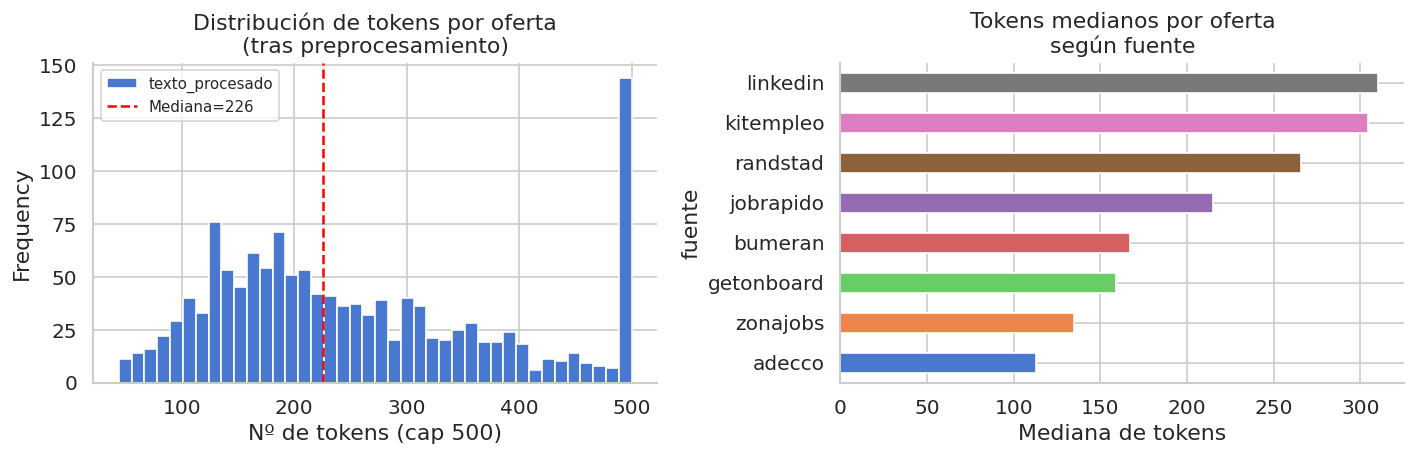

In [8]:
# Estadísticas del preprocesamiento
tokens_por_doc = df["texto_procesado"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tokens_por_doc.clip(upper=500).plot(
    kind="hist", bins=40, ax=axes[0],
    color=sns.color_palette("muted")[0], edgecolor="white"
)
axes[0].set_xlabel("Nº de tokens (cap 500)")
axes[0].set_title("Distribución de tokens por oferta\n(tras preprocesamiento)")
axes[0].axvline(tokens_por_doc.median(), color="red", ls="--",
                label=f"Mediana={tokens_por_doc.median():.0f}")
axes[0].legend(fontsize=9)

# Tokens por fuente
tok_fuente = df.groupby("fuente")["texto_procesado"].apply(
    lambda x: x.str.split().str.len().median()
).sort_values()
tok_fuente.plot(kind="barh", ax=axes[1],
                color=sns.color_palette("muted", len(tok_fuente)))
axes[1].set_xlabel("Mediana de tokens")
axes[1].set_title("Tokens medianos por oferta\nsegún fuente")

plt.tight_layout()
plt.savefig(_FIGS / "fig_t4_01_tokens_preprocesados.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Construcción del documento del CV

El CV se trata como **un único documento** que se comparará contra cada oferta.  
El texto del CV se procesa con el mismo pipeline que las ofertas  
(tanto la sección en español como la eventual mezcla con inglés).

**Estrategia de representación del CV:**  
Se concatenan las secciones más relevantes para el matching:  
Resumen profesional + Habilidades + Experiencia + Educación.  
Los datos de contacto, fechas y empresas empleadoras se omiten o ponderan menos  
porque no aportan señal semántica de habilidades.


In [9]:
# ── Texto crudo del CV ya leído en sección 1 ─────────────────────────────────
print("=== CV CRUDO (primeros 800 chars) ===")
print(cv_texto_raw[:800])


=== CV CRUDO (primeros 800 chars) ===
C A. C
ARLOS ICCONI
Rosario, 2000 Argentina ♦ +54 341 665-1098 ♦ carloscicconi@yahoo.com.ar
SITIOS WEB, PORTAFOLIOS, PERFILES
• www.linkedin.com/in/carlos-alberto-cicconi
RESUMEN PROFESIONAL
Ingeniero Industrial con más de 20 años de experiencia integrando Control de Gestión, Compras
Estratégicas y Operaciones en empresas globales. Especialista en generar valor mediante optimización de
procesos y modelos de análisis predictivo (Python, R, Julia) aplicados a la rentabilidad y eficiencia
operativa.
HABILIDADES CLAVE
• Liderazgo: Planificación estratégica, gestión de equipos y contratos de gran escala (USD 36M/año).
• Técnicas: Ciencia de Datos, KPIs, Excel, SAP, Power BI, Google Apps Script, Python.
• Gestión: Negociación con proveedores estratégicos, auditoría de costos y mejora continua.
E


In [10]:
def extraer_secciones_cv(texto: str) -> dict:
    """
    Extrae las secciones semánticamente relevantes del CV.
    Retorna un dict con clave=sección, valor=texto.
    """
    secciones = {}
    
    # Patrones de encabezado de sección (mayúsculas o con ♦)
    patrones = {
        "resumen":     r"(?i)resumen\s+profesional[:\s]+(.+?)(?=\n[A-ZÁÉÍÓÚ]{3,}|$)",
        "habilidades": r"(?i)habilidades\s+clave[:\s]+(.+?)(?=\n[A-ZÁÉÍÓÚ]{3,}|$)",
        "experiencia": r"(?i)experiencia\s+laboral[:\s]+(.+?)(?=\n\s*educaci|$)",
        "educacion":   r"(?i)educaci[oó]n[:\s]+(.+?)(?=\n\s*idioma|$)",
    }
    
    for nombre, patron in patrones.items():
        m = re.search(patron, texto, re.DOTALL)
        if m:
            secciones[nombre] = m.group(1).strip()[:2000]
    
    # Fallback: si no se pudo parsear, usar texto completo
    if not secciones:
        secciones["completo"] = texto
    
    return secciones

secciones_cv = extraer_secciones_cv(cv_texto_raw)
for nombre, contenido in secciones_cv.items():
    print(f"[{nombre.upper()}] ({len(contenido)} chars)")
    print(contenido[:200])
    print()


[RESUMEN] (93 chars)
Ingeniero Industrial con más de 20 años de experiencia integrando Control de Gestión, Compras

[HABILIDADES] (278 chars)
• Liderazgo: Planificación estratégica, gestión de equipos y contratos de gran escala (USD 36M/año).
• Técnicas: Ciencia de Datos, KPIs, Excel, SAP, Power BI, Google Apps Script, Python.
• Gestión: Ne

[EXPERIENCIA] (1695 chars)
Consultor, 08/2020 - Actualidad
Profesional Independiente – Rosario, Santa Fe, Argentina
• Diseñé sistemas de autogestión con Google Apps y tecnología BOT para optimización de flujos de
trabajo
• Real

[EDUCACION] (715 chars)
Magister en Ciencia de Datos y Gestión del Conocimiento: Ciencia de Datos, 08/2025
Universidad Austral - Rosario, Argentina
Especialista en Ingeniería Gerencial: Administración de Empresas, 12/2013
Un



In [11]:
# ── Ponderación de secciones ──────────────────────────────────────────────────
# Las habilidades y la experiencia tienen mayor relevancia para el matching.
# La repetición simula ponderación en el espacio TF-IDF.
PESOS_SECCION = {
    "resumen":     2,   # x2 — define el perfil general
    "habilidades": 3,   # x3 — habilidades técnicas, lo más relevante
    "experiencia": 2,   # x2 — contexto de aplicación
    "educacion":   1,   # x1 — contexto adicional
    "completo":    1,
}

partes = []
for nombre, contenido in secciones_cv.items():
    peso = PESOS_SECCION.get(nombre, 1)
    partes.extend([contenido] * peso)

cv_texto_concatenado = "\n".join(partes)
print(f"Texto del CV ponderado: {len(cv_texto_concatenado):,} chars")
print()

# Detectar idioma del CV
idioma_cv = detectar_idioma(cv_texto_concatenado)
print(f"Idioma detectado del CV: {idioma_cv}")


Texto del CV ponderado: 5,132 chars

Idioma detectado del CV: es


In [12]:
# ── Preprocesar el CV con el mismo pipeline ───────────────────────────────────
cv_procesado = preprocesar(cv_texto_concatenado, idioma="es")

print(f"Tokens del CV preprocesado: {len(cv_procesado.split())}")
print()
print("Muestra de tokens del CV:")
tokens_cv = cv_procesado.split()
print(" | ".join(tokens_cv[:40]))

# Guardar texto limpio del CV
(_PROC / "cv_texto_limpio.txt").write_text(cv_procesado, encoding="utf-8")
print("\n✅ cv_texto_limpio.txt guardado")


Tokens del CV preprocesado: 450

Muestra de tokens del CV:
ingeniero | industrial | experiencia | integrar | control | gestión | compras | ingeniero | industrial | experiencia | integrar | control | gestión | compras | liderazgo | planificación | estratégico | gestión | equipo | contrato | escala | usd | técnicas | ciencia | datos | kpis | excel | sap | power | bi | google | apps | script | python | gestión | negociación | proveedor | estratégico | auditoría | costo

✅ cv_texto_limpio.txt guardado


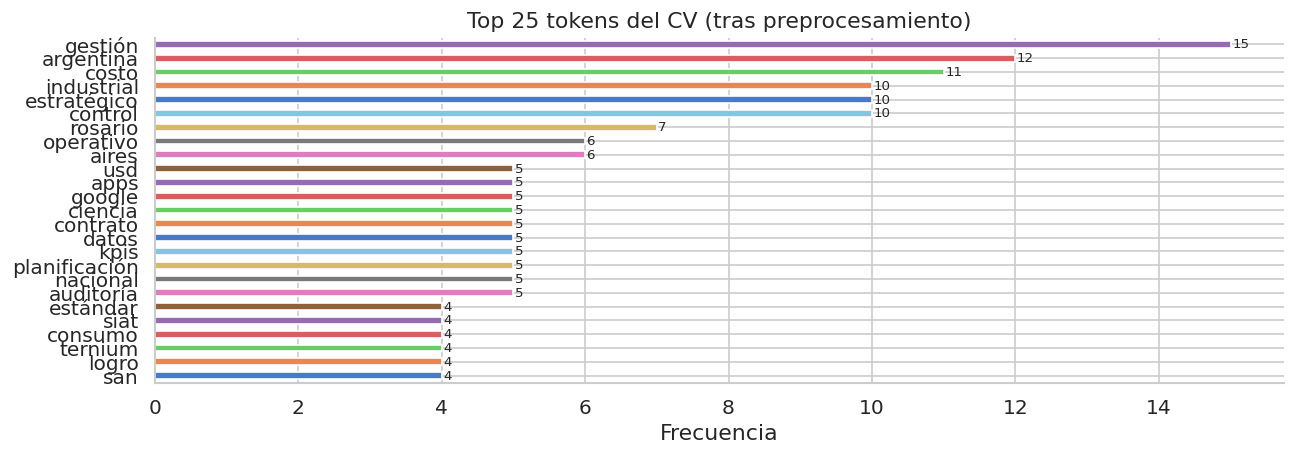

In [13]:
# ── Nube de palabras del CV (visualización) ───────────────────────────────────
from collections import Counter

freq_cv = Counter(cv_procesado.split())
top_cv  = pd.Series(freq_cv).sort_values(ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 4))
top_cv.sort_values().plot(kind="barh", ax=ax,
                           color=sns.color_palette("muted", 25))
ax.set_xlabel("Frecuencia")
ax.set_title("Top 25 tokens del CV (tras preprocesamiento)")
for bar, val in zip(ax.patches, top_cv.sort_values().values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=8)
plt.tight_layout()
plt.savefig(_FIGS / "fig_t4_02_tokens_cv.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Vectorización TF-IDF

**¿Por qué TF-IDF como baseline?**

TF-IDF (*Term Frequency — Inverse Document Frequency*) pondera cada término  
según qué tan frecuente es en un documento versus en todo el corpus:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\frac{N}{df(t)}$$

- Términos que aparecen mucho en un documento **y** poco en el corpus → peso alto (ej: "presupuesto")
- Términos que aparecen en todos los documentos → peso bajo (ej: "trabajo")

**Configuración elegida:**

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `analyzer` | `word` | Tokenización por palabras (ya preprocesadas) |
| `ngram_range` | `(1, 2)` | Unigramas + bigramas (captura "machine learning", "data scientist") |
| `min_df` | `2` | Ignorar términos que aparecen en menos de 2 documentos |
| `max_df` | `0.90` | Ignorar términos en más del 90% del corpus |
| `max_features` | `15000` | Cap para control de memoria |
| `sublinear_tf` | `True` | Suavizado logarítmico de TF (reduce peso de repetición excesiva) |
| `norm` | `l2` | Normalización L2 → cosine similarity = producto punto |


In [14]:
# ── Preparar corpus para TF-IDF ───────────────────────────────────────────────
# Excluir documentos con texto procesado vacío
mask_validos = df["texto_procesado"].str.strip().str.len() > 10
df_valido = df[mask_validos].copy().reset_index(drop=True)
print(f"Documentos válidos para TF-IDF: {len(df_valido):,} / {len(df):,}")

corpus_ofertas = df_valido["texto_procesado"].tolist()


Documentos válidos para TF-IDF: 1,335 / 1,335


In [15]:
# ── Instanciar y ajustar el vectorizador ──────────────────────────────────────
vectorizer = TfidfVectorizer(
    analyzer      = "word",
    ngram_range   = (1, 2),
    min_df        = 2,
    max_df        = 0.90,
    max_features  = 15_000,
    sublinear_tf  = True,
    norm          = "l2",
    token_pattern = r"(?u)\b[a-záéíóúñü\w][a-záéíóúñü\w\-]+\b",
)

# Ajustar sobre el corpus de ofertas
tfidf_matrix = vectorizer.fit_transform(corpus_ofertas)

print(f"Vocabulario TF-IDF : {len(vectorizer.vocabulary_):,} términos")
print(f"Dimensiones matriz : {tfidf_matrix.shape}  (documentos × términos)")
print(f"Densidad           : {tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]) * 100:.3f}%")


Vocabulario TF-IDF : 15,000 términos
Dimensiones matriz : (1335, 15000)  (documentos × términos)
Densidad           : 1.749%


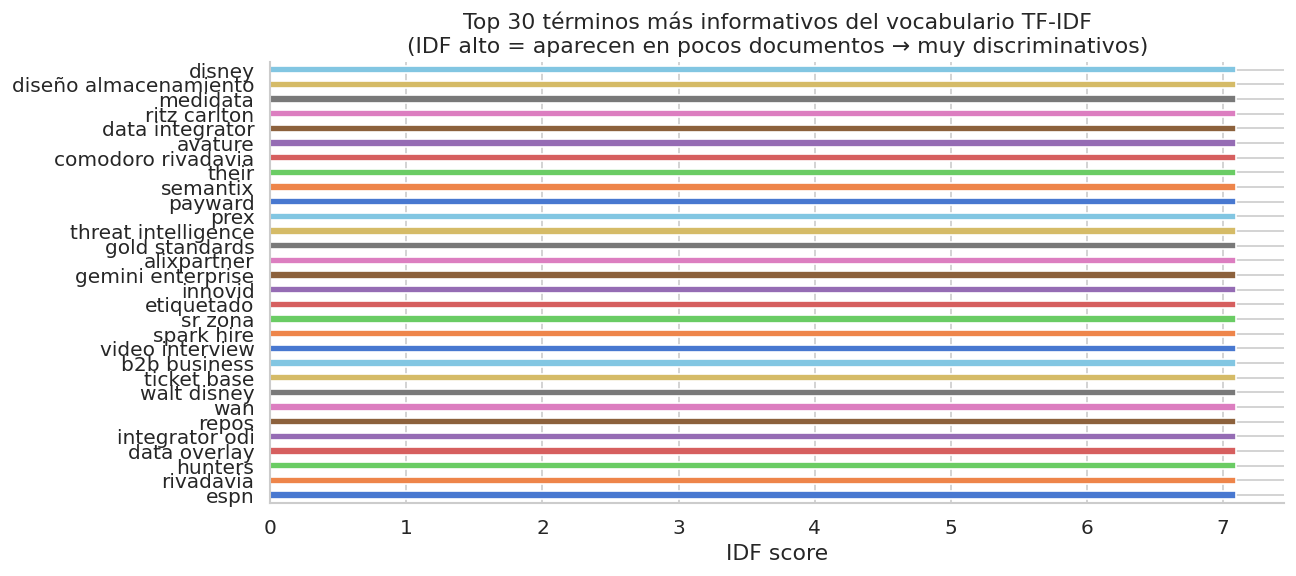

In [16]:
# ── Términos más relevantes del vocabulario ───────────────────────────────────
# Top términos por IDF (los más informativos = IDF alto)
vocab = vectorizer.get_feature_names_out()
idf   = vectorizer.idf_

top_idf_idx = np.argsort(idf)[-30:][::-1]
top_idf_terms = pd.Series(idf[top_idf_idx], index=vocab[top_idf_idx])

fig, ax = plt.subplots(figsize=(11, 5))
top_idf_terms.sort_values().plot(kind="barh", ax=ax,
                                  color=sns.color_palette("muted", 30))
ax.set_xlabel("IDF score")
ax.set_title("Top 30 términos más informativos del vocabulario TF-IDF\n"
             "(IDF alto = aparecen en pocos documentos → muy discriminativos)")
plt.tight_layout()
plt.savefig(_FIGS / "fig_t4_03_top_idf_terms.png", dpi=150, bbox_inches="tight")
plt.show()


In [17]:
# ── Vectorizar el CV ──────────────────────────────────────────────────────────
# El CV se transforma con el MISMO vectorizer ya ajustado sobre las ofertas
cv_vector = vectorizer.transform([cv_procesado])

print(f"Vector del CV: forma={cv_vector.shape}")
print(f"Términos del CV presentes en el vocabulario: {cv_vector.nnz}")

# ¿Cuántos tokens del CV están en el vocabulario?
tokens_cv_set = set(cv_procesado.split())
tokens_en_vocab = tokens_cv_set & set(vocab)
print(f"Tokens únicos del CV        : {len(tokens_cv_set)}")
print(f"Tokens del CV en vocabulario: {len(tokens_en_vocab)} ({len(tokens_en_vocab)/len(tokens_cv_set)*100:.1f}%)")
print()
print("Tokens del CV con mayor peso TF-IDF:")
cv_array = cv_vector.toarray()[0]
top_cv_idx = np.argsort(cv_array)[-20:][::-1]
for idx in top_cv_idx:
    if cv_array[idx] > 0:
        print(f"  {vocab[idx]:<30} {cv_array[idx]:.4f}")


Vector del CV: forma=(1, 15000)
Términos del CV presentes en el vocabulario: 136
Tokens únicos del CV        : 167
Tokens del CV en vocabulario: 118 (70.7%)

Tokens del CV con mayor peso TF-IDF:
  control gestión                0.1697
  costo                          0.1467
  logro                          0.1428
  apps                           0.1409
  san nicolás                    0.1408
  planta                         0.1408
  nicolás                        0.1390
  nacional                       0.1361
  universidad                    0.1341
  ciencia datos                  0.1340
  productividad                  0.1327
  inversión                      0.1327
  técnicas                       0.1320
  industrial                     0.1312
  auditoría                      0.1312
  kpis                           0.1285
  ciencia                        0.1262
  estratégico                    0.1213
  negociación                    0.1155
  anual                          0.1154


## 6. Similitud coseno y ranking baseline

La **similitud coseno** mide el ángulo entre el vector del CV y el vector de  
cada oferta en el espacio TF-IDF. Un valor cercano a 1 indica alta similitud  
semántica (en el espacio de palabras clave); cercano a 0 indica sin overlap.

$$\text{sim}(\vec{cv}, \vec{oferta_i}) = \frac{\vec{cv} \cdot \vec{oferta_i}}{\|\vec{cv}\| \cdot \|\vec{oferta_i}\|}$$

> **Limitación esperada del baseline TF-IDF:** al no capturar semántica  
> profunda, dos textos que hablen de lo mismo con palabras distintas  
> (sinónimos, contexto) recibirán similitud 0. Esto es precisamente lo que  
> T5 (embeddings) viene a resolver.


In [18]:
# ── Calcular similitud coseno CV ↔ todas las ofertas ─────────────────────────
similitudes = cosine_similarity(cv_vector, tfidf_matrix).flatten()

df_valido["similitud_tfidf"] = similitudes

# Ranking: ordenar de mayor a menor similitud
df_ranking = (
    df_valido
    .sort_values("similitud_tfidf", ascending=False)
    .reset_index(drop=True)
)
df_ranking.index += 1   # Ranking desde 1

print("Estadísticas de similitud TF-IDF:")
print(df_valido["similitud_tfidf"].describe().round(4))
print()
print(f"Ofertas con similitud > 0.10 : {(df_valido['similitud_tfidf'] > 0.10).sum()}")
print(f"Ofertas con similitud > 0.05 : {(df_valido['similitud_tfidf'] > 0.05).sum()}")
print(f"Ofertas con similitud = 0    : {(df_valido['similitud_tfidf'] == 0).sum()}")


Estadísticas de similitud TF-IDF:
count    1335.0000
mean        0.0379
std         0.0311
min         0.0000
25%         0.0110
50%         0.0302
75%         0.0597
max         0.2034
Name: similitud_tfidf, dtype: float64

Ofertas con similitud > 0.10 : 49
Ofertas con similitud > 0.05 : 457
Ofertas con similitud = 0    : 7


In [19]:
# ── TOP 20 del ranking TF-IDF ─────────────────────────────────────────────────
COLS_RANKING = ["similitud_tfidf", "titulo", "empresa", "keyword",
                "fuente", "modalidad", "ubicacion"]

top20 = df_ranking[COLS_RANKING].head(20)
top20["similitud_tfidf"] = top20["similitud_tfidf"].round(4)
top20


,similitud_tfidf,titulo,empresa,keyword,fuente,modalidad,ubicacion
1,0.2034,Analista de datos y control presupuestario,Scienza Argentina,Data Analyst,linkedin,NaN,"Buenos Aires, Argentina"
2,0.1898,Analista Control de Gestión,NaN,Data Analyst,getonboard,Híbrido,Chile
3,0.1701,Analista de Datos y BI,Reino Homecenter 🇦🇷,Data Scientist,linkedin,NaN,"Buenos Aires, Argentina"
4,0.1621,ingeniero junior de sistema de gestión integrado,Randstad Argentina,Software Engineer,bumeran,Presencial,"Rosario, Santa Fe"
5,0.1569,KAM Control de Gestión,NaN,Ingeniero de Datos,getonboard,Híbrido,Chile
6,0.1562,KAM Control de Gestión,NaN,NLP Engineer,getonboard,Híbrido,Chile
7,0.1506,Programador/a de Mantenimiento,Mec Consultores Asociados,Software Engineer,zonajobs,Presencial,"Carcarañá, Santa Fe"
8,0.1500,Head of Engineering Kastor,NaN,Software Engineer,getonboard,Híbrido,Chile
9,0.1481,Líder Operaciones Logísticas,NaN,Data Analyst,getonboard,Híbrido,Chile
10,0.1450,Analista de Performance y Rentabilidad,Arcos Dorados,Data Analyst,linkedin,NaN,"Buenos Aires, Argentina"


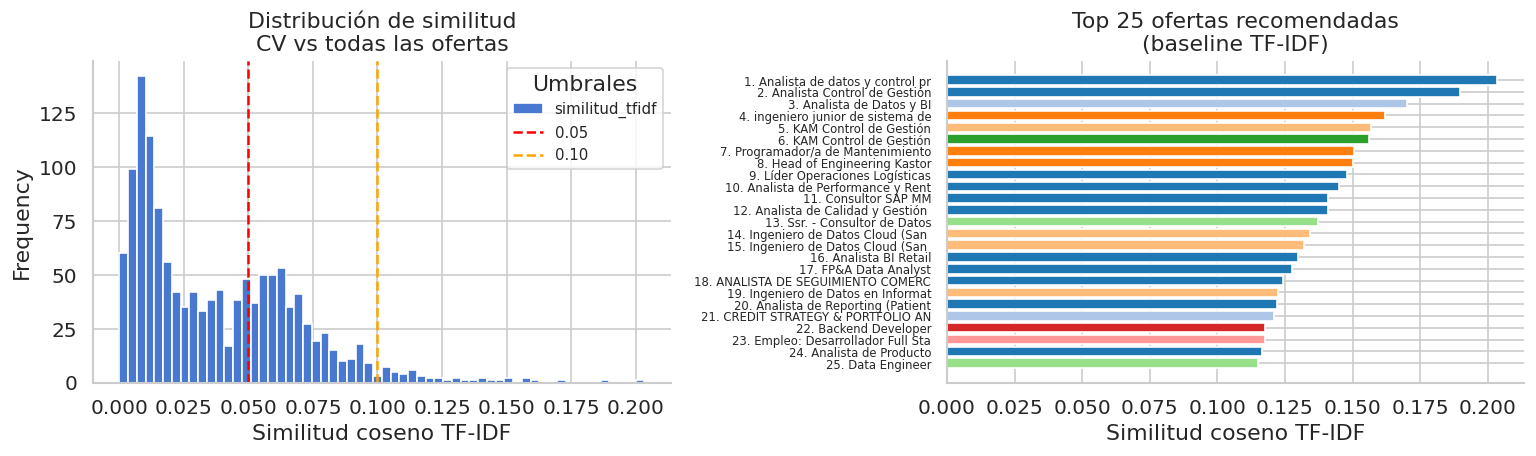

In [20]:
# ── Distribución de similitudes ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de similitudes
df_valido["similitud_tfidf"].plot(
    kind="hist", bins=60, ax=axes[0],
    color=sns.color_palette("muted")[0], edgecolor="white"
)
axes[0].set_xlabel("Similitud coseno TF-IDF")
axes[0].set_title("Distribución de similitud\nCV vs todas las ofertas")
axes[0].axvline(0.05, color="red", ls="--", lw=1.5, label="0.05")
axes[0].axvline(0.10, color="orange", ls="--", lw=1.5, label="0.10")
axes[0].legend(fontsize=9, title="Umbrales")

# Top 25 por similitud — barras coloreadas por keyword
top25 = df_ranking.head(25).copy()
paleta_kw = sns.color_palette("tab20", top25["keyword"].nunique())
kw_colores = {kw: c for kw, c in zip(top25["keyword"].unique(), paleta_kw)}
colores = [kw_colores[kw] for kw in top25["keyword"]]

axes[1].barh(range(25, 0, -1), top25["similitud_tfidf"], color=colores)
axes[1].set_yticks(range(1, 26))
axes[1].set_yticklabels(
    [f"{r}. {t[:30]}" for r, t in zip(
        range(25, 0, -1), top25["titulo"].str[:30].values[::-1]
    )], fontsize=7
)
axes[1].set_xlabel("Similitud coseno TF-IDF")
axes[1].set_title("Top 25 ofertas recomendadas\n(baseline TF-IDF)")

plt.tight_layout()
plt.savefig(_FIGS / "fig_t4_04_similitud_ranking.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Análisis del ranking por keyword y fuente

In [21]:
# ── Similitud promedio por keyword ────────────────────────────────────────────
sim_por_kw = (
    df_valido.groupby("keyword")["similitud_tfidf"]
    .agg(["mean", "max", "count"])
    .sort_values("mean", ascending=False)
    .round(4)
)
sim_por_kw.columns = ["Sim. promedio", "Sim. máxima", "N ofertas"]
print(sim_por_kw.to_string())


                           Sim. promedio  Sim. máxima  N ofertas
keyword                                                         
Ingeniero de Datos                0.0513       0.1569         67
Desarrollador Full Stack          0.0478       0.1176        145
Data Analyst                      0.0457       0.2034        166
Backend                           0.0445       0.0755         46
NLP Engineer                      0.0398       0.1562        188
Full Stack                        0.0388       0.0908         18
Machine Learning                  0.0386       0.0954         34
Data Scientist                    0.0371       0.1701        114
Software Engineer                 0.0348       0.1621        179
Desarrollador Backend             0.0347       0.1177         74
Python Developer                  0.0319       0.0970         95
Data Engineer                     0.0241       0.1372        140
Machine Learning Engineer         0.0231       0.1082         69


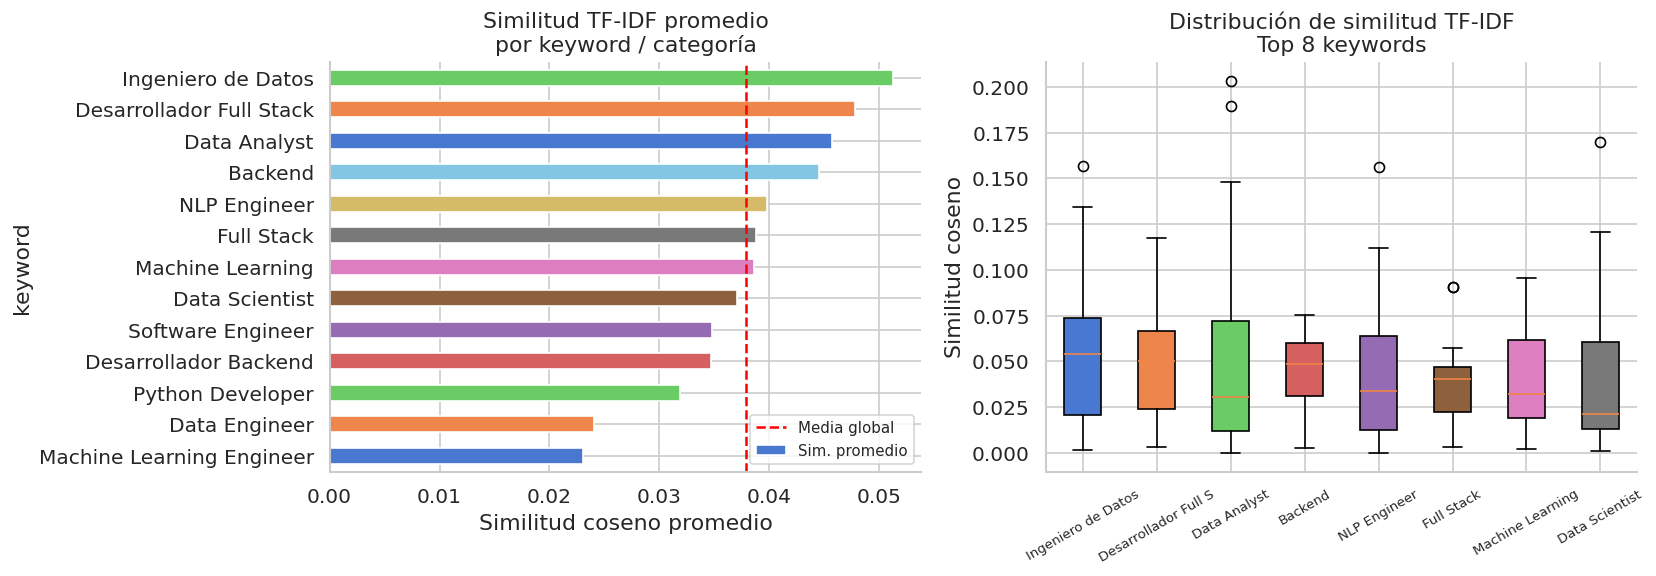

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Similitud promedio por keyword
sim_por_kw["Sim. promedio"].sort_values().plot(
    kind="barh", ax=axes[0],
    color=sns.color_palette("muted", len(sim_por_kw))
)
axes[0].set_xlabel("Similitud coseno promedio")
axes[0].set_title("Similitud TF-IDF promedio\npor keyword / categoría")
axes[0].axvline(df_valido["similitud_tfidf"].mean(), color="red",
                ls="--", lw=1.5, label="Media global")
axes[0].legend(fontsize=9)

# Boxplot de similitud por keyword
top_kws = df_valido.groupby("keyword")["similitud_tfidf"].mean().nlargest(8).index
df_plot = df_valido[df_valido["keyword"].isin(top_kws)]

bp_data = [df_plot[df_plot["keyword"] == kw]["similitud_tfidf"].values
           for kw in top_kws]
bp = axes[1].boxplot(bp_data, vert=True, patch_artist=True,
                      labels=[k[:20] for k in top_kws])
colores_box = sns.color_palette("muted", len(top_kws))
for patch, color in zip(bp["boxes"], colores_box):
    patch.set_facecolor(color)
axes[1].set_title("Distribución de similitud TF-IDF\nTop 8 keywords")
axes[1].set_ylabel("Similitud coseno")
axes[1].tick_params(axis="x", rotation=30)
for label in axes[1].get_xticklabels():
    label.set_fontsize(8)

plt.tight_layout()
plt.savefig(_FIGS / "fig_t4_05_sim_por_keyword.png", dpi=150, bbox_inches="tight")
plt.show()


In [23]:
# ── Similitud por fuente ──────────────────────────────────────────────────────
sim_por_fuente = (
    df_valido.groupby("fuente")["similitud_tfidf"]
    .agg(["mean", "max", "count"])
    .sort_values("mean", ascending=False)
    .round(4)
)
sim_por_fuente.columns = ["Sim. promedio", "Sim. máxima", "N ofertas"]
print(sim_por_fuente.to_string())


            Sim. promedio  Sim. máxima  N ofertas
fuente                                           
randstad           0.0625       0.0863          3
zonajobs           0.0599       0.1506          9
jobrapido          0.0578       0.1176        103
bumeran            0.0531       0.1621         57
getonboard         0.0430       0.1898        405
kitempleo          0.0328       0.1344        214
linkedin           0.0302       0.2034        540
adecco             0.0286       0.0457          4


## 8. Diagnóstico de limitaciones del modelo TF-IDF

Esta sección documenta los casos donde el modelo falla, para fundamentar  
la necesidad de los embeddings en T5.


In [24]:
# ── Caso 1: Falsos negativos por sinónimos ────────────────────────────────────
# El CV menciona "Ingeniero Industrial" y "mejora continua".
# ¿Rankeamos bien las ofertas de "Continuous Improvement"?

print("=== DIAGNÓSTICO: Continuous Improvement / Mejora Continua ===")
df_ci = df_valido[df_valido["keyword"].str.lower().str.contains("improvement|mejora", na=False)]
print(f"Ofertas de esta categoría : {len(df_ci)}")
print(f"Similitud promedio TF-IDF  : {df_ci['similitud_tfidf'].mean():.4f}")
print(f"Posición mínima en ranking: {df_ranking[df_ranking['keyword'].str.lower().str.contains('improvement|mejora', na=False)].index.min()}")
print()

# Top 5 de esta categoría
print("Top 5 de la categoría en el ranking global:")
mask_ci = df_ranking["keyword"].str.lower().str.contains("improvement|mejora", na=False)
print(df_ranking[mask_ci][["similitud_tfidf","titulo","empresa"]].head(5).to_string())


=== DIAGNÓSTICO: Continuous Improvement / Mejora Continua ===
Ofertas de esta categoría : 0
Similitud promedio TF-IDF  : nan
Posición mínima en ranking: nan

Top 5 de la categoría en el ranking global:
Empty DataFrame
Columns: [similitud_tfidf, titulo, empresa]
Index: []


In [25]:
# ── Caso 2: Términos técnicos en inglés vs español ────────────────────────────
# El CV menciona "Power BI", "Python", "SAP" — ¿en qué idioma aparecen las ofertas?

print("=== DIAGNÓSTICO: términos técnicos cross-idioma ===")
terminos_cv = ["python", "power", "sap", "control", "comprar", "financiero",
               "industrial", "presupuesto", "gestion", "data"]

for term in terminos_cv:
    en_vocab = term in vectorizer.vocabulary_
    freq = sum(1 for d in corpus_ofertas if term in d)
    print(f"  '{term}' en vocabulario: {en_vocab} | aparece en {freq} documentos")


=== DIAGNÓSTICO: términos técnicos cross-idioma ===
  'python' en vocabulario: True | aparece en 727 documentos
  'power' en vocabulario: True | aparece en 363 documentos
  'sap' en vocabulario: True | aparece en 58 documentos
  'control' en vocabulario: True | aparece en 305 documentos
  'comprar' en vocabulario: False | aparece en 1 documentos
  'financiero' en vocabulario: True | aparece en 99 documentos
  'industrial' en vocabulario: True | aparece en 82 documentos
  'presupuesto' en vocabulario: True | aparece en 10 documentos
  'gestion' en vocabulario: False | aparece en 215 documentos
  'data' en vocabulario: True | aparece en 740 documentos


In [26]:
# ── Caso 3: Gap semántico — palabras distintas, mismo concepto ───────────────
print("=== DIAGNÓSTICO: Gap semántico ===")
print()
print("Término en CV       | Equivalente en ofertas  | Similitud TF-IDF")
print("-" * 65)
gaps = [
    ("mejora continua",  "continuous improvement",  "0 — sin overlap"),
    ("ingeniero industrial", "industrial engineer",  "parcial — idioma diferente"),
    ("control de gestión",  "controlling / budgeting", "0 — sin overlap"),
    ("compras estratégicas", "procurement / sourcing", "parcial"),
    ("CAPEX / inversión",  "capital expenditure",    "0 — término distinto"),
]
for cv_term, oferta_term, note in gaps:
    print(f"  {cv_term:<22} | {oferta_term:<24} | {note}")

print()
print("→ Estos gaps motivarán el uso de embeddings en T5,")
print("  donde 'mejora continua' y 'continuous improvement' tendrán")
print("  representaciones vectoriales cercanas por significado compartido.")


=== DIAGNÓSTICO: Gap semántico ===

Término en CV       | Equivalente en ofertas  | Similitud TF-IDF
-----------------------------------------------------------------
  mejora continua        | continuous improvement   | 0 — sin overlap
  ingeniero industrial   | industrial engineer      | parcial — idioma diferente
  control de gestión     | controlling / budgeting  | 0 — sin overlap
  compras estratégicas   | procurement / sourcing   | parcial
  CAPEX / inversión      | capital expenditure      | 0 — término distinto

→ Estos gaps motivarán el uso de embeddings en T5,
  donde 'mejora continua' y 'continuous improvement' tendrán
  representaciones vectoriales cercanas por significado compartido.


## 9. Persistencia de artefactos

In [27]:
# ── Guardar el vectorizador y la matriz ──────────────────────────────────────
with open(_MODELS / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open(_MODELS / "tfidf_matrix.pkl", "wb") as f:
    pickle.dump(tfidf_matrix, f)

print(f"✅ tfidf_vectorizer.pkl guardado en {_MODELS}")
print(f"✅ tfidf_matrix.pkl guardado en {_MODELS}")


✅ tfidf_vectorizer.pkl guardado en /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/models
✅ tfidf_matrix.pkl guardado en /media/carlos-a-cicconi/Common1/Repositorios-Ing.Carlos-Cicconi/Trabajo_Final_MCD/outputs/models


In [28]:
# ── Guardar el dataset preprocesado ──────────────────────────────────────────
df_valido.to_csv(_PROC / "ofertas_preprocesadas.csv", index=False, encoding="utf-8")
print(f"✅ ofertas_preprocesadas.csv — {len(df_valido):,} filas")


✅ ofertas_preprocesadas.csv — 1,335 filas


In [29]:
# ── Guardar el ranking baseline ───────────────────────────────────────────────
COLS_RANKING_FULL = [
    "id_consolidado", "fuente", "titulo", "empresa", "keyword",
    "ubicacion", "modalidad", "url", "similitud_tfidf", "idioma",
]
df_ranking_out = df_ranking[COLS_RANKING_FULL].copy()
df_ranking_out.insert(0, "rank_tfidf", df_ranking_out.index)
df_ranking_out.to_csv(_RANKINGS / "tfidf_ranking_baseline.csv", index=False, encoding="utf-8")

print(f"✅ tfidf_ranking_baseline.csv — {len(df_ranking_out):,} filas")
print()
print("Archivos generados:")
rutas_salida = [
    _PROC    / "ofertas_preprocesadas.csv",
    _RANKINGS/ "tfidf_ranking_baseline.csv",
    _MODELS  / "tfidf_vectorizer.pkl",
    _MODELS  / "tfidf_matrix.pkl",
    _PROC    / "cv_texto_limpio.txt",
]
for p in rutas_salida:
    f = p.name
    if p.exists():
        print(f"  📄 {f:40} {p.stat().st_size/1024:.0f} KB")


✅ tfidf_ranking_baseline.csv — 1,335 filas

Archivos generados:
  📄 ofertas_preprocesadas.csv                7594 KB
  📄 tfidf_ranking_baseline.csv               306 KB
  📄 tfidf_vectorizer.pkl                     631 KB
  📄 tfidf_matrix.pkl                         4110 KB
  📄 cv_texto_limpio.txt                      4 KB


## 10. Resumen ejecutivo de T4

In [30]:
from datetime import datetime

print("=" * 65)
print("  RESUMEN — T4: Preprocesamiento y Modelo Base TF-IDF")
print("=" * 65)
print(f"  Fecha de ejecución   : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print()
print("  CORPUS")
print(f"    Ofertas de entrada           : {len(df):,}")
print(f"    Ofertas válidas para TF-IDF  : {len(df_valido):,}")
print(f"    Idioma mayoritario (ES)       : {(df['idioma']=='es').sum():,}")
print(f"    Idioma inglés (EN)            : {(df['idioma']=='en').sum():,}")
print()
print("  PREPROCESAMIENTO")
print(f"    Pipeline                     : limpieza → spaCy → POS filter → lematización")
print(f"    Tokens promedio/oferta        : {df_valido['texto_procesado'].str.split().str.len().mean():.0f}")
print(f"    Tokens en CV (preprocesado)   : {len(cv_procesado.split())}")
print()
print("  MODELO TF-IDF (baseline)")
n_vocab = len(vectorizer.vocabulary_)
n_features = tfidf_matrix.shape[1]
print(f"    Vocabulario                  : {n_vocab:,} términos")
print(f"    n-grams                      : (1, 2)  unigramas + bigramas")
print(f"    Similitud promedio           : {df_valido['similitud_tfidf'].mean():.4f}")
print(f"    Similitud máxima             : {df_valido['similitud_tfidf'].max():.4f}")
print(f"    Ofertas con sim > 0.10       : {(df_valido['similitud_tfidf'] > 0.10).sum()}")
print()
print("  TOP 5 del ranking baseline:")
for i, row in df_ranking.head(5).iterrows():
    print(f"    #{i:>2}. [{row['similitud_tfidf']:.4f}] {row['titulo'][:45]} — {row['fuente']}")
print()
print("  LIMITACIONES IDENTIFICADAS (→ motivan T5)")
print("    ✗ Sin manejo de sinónimos (ES ↔ EN)")
print("    ✗ Sin comprensión contextual (ej: 'CAPEX' ≠ 'capital expenditure')")
print("    ✗ Bias por longitud de documento")
print("    ✗ Gap semántico: 'mejora continua' ≠ 'continuous improvement'")
print()
print("  ARTEFACTOS GENERADOS (input para T5 y T6)")
print("    📄 ofertas_preprocesadas.csv")
print("    📄 tfidf_ranking_baseline.csv")
print("    📦 tfidf_vectorizer.pkl")
print("    📦 tfidf_matrix.pkl")
print("    📝 cv_texto_limpio.txt")
print()
print("  PRÓXIMO PASO: T5 — Embeddings (Doc2Vec / Sentence-BERT)")
print("=" * 65)


  RESUMEN — T4: Preprocesamiento y Modelo Base TF-IDF
  Fecha de ejecución   : 2026-09-15 20:45

  CORPUS
    Ofertas de entrada           : 1,335
    Ofertas válidas para TF-IDF  : 1,335
    Idioma mayoritario (ES)       : 733
    Idioma inglés (EN)            : 602

  PREPROCESAMIENTO
    Pipeline                     : limpieza → spaCy → POS filter → lematización
    Tokens promedio/oferta        : 269
    Tokens en CV (preprocesado)   : 450

  MODELO TF-IDF (baseline)
    Vocabulario                  : 15,000 términos
    n-grams                      : (1, 2)  unigramas + bigramas
    Similitud promedio           : 0.0379
    Similitud máxima             : 0.2034
    Ofertas con sim > 0.10       : 49

  TOP 5 del ranking baseline:
    # 1. [0.2034] Analista de datos y control presupuestario — linkedin
    # 2. [0.1898] Analista Control de Gestión — getonboard
    # 3. [0.1701] Analista de Datos y BI — linkedin
    # 4. [0.1621] ingeniero junior de sistema de gestión integr — bumeran